# Pre-processing Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from collections import Counter

import os
import sys
import json

# Helper functions for data collection
from scripts.collect_helper import check_cluster, pull_logs, get_collection_stats

import warnings
warnings.filterwarnings('ignore')

## Connect to K8s cluster & Get all pods

In [2]:
check_cluster()

  Cluster Info



Total Nodes:
NAME              STATUS   ROLES           AGE   VERSION
217.216.110.115   Ready    worker          9d    v1.30.14
217.217.255.103   Ready    control-plane   9d    v1.30.14

Benign Pods:
NAME                                READY   STATUS             RESTARTS         AGE
flask-postgres-7578c9f547-w7tt8     1/1     Running            0                13h
flask-todo-7459f5dbdb-cs8hp         1/1     Running            0                13h
flask-todo-7459f5dbdb-q528r         1/1     Running            0                13h
mariadb-sysbench-57d5f78654-64r4t   1/1     Running            0                13h
media-streaming-bcf5ffd4c-g8fzw     1/1     Running            0                13h
memcached-server-7dbc55b66b-b2c6q   1/1     Running            0                13h
sysbench                            0/1     CrashLoopBackOff   24 (5m13s ago)   105m
sysbench-workload-bgjvb             0/1     Completed          0                13h
web-serving-app-74ffff7cd6-v9tpj    0/1   

True

## Data Collection

Pull logs from Cilium dan Tetragon

In [3]:
pull_logs(sessions=5, interval=300, stimulate=True)
get_collection_stats()

  K-IDS Multi-Session Data Collection
  Sessions : 5
  Interval : 300s (5 min)
  Stimulate: True
  Est. time: ~20 minutes

Running: bash /mnt/nvme0n1p11/Github/project-kIDS/feature_engineering/scripts/collect_data.sh --sessions 5 --interval 300 --stimulate


 K-IDS Multi-Session Data Collector

  Sessions  : 5
  Interval  : 300s
  Stimulate : true
  Output    : /mnt/nvme0n1p11/Github/project-kIDS/feature_engineering/raw_logs

[STEP]  09:28:14 Running pre-flight checks...


dirname: unrecognized option '--sessions'
Try 'dirname --help' for more information.


[INFO]  09:28:15 Cluster connection: OK
[INFO]  09:28:15 Tetragon pods: 2
[INFO]  09:28:16 Cilium pods: 2

[STEP]  09:28:16 Workload status:
  Benign workloads:
    flask-postgres-7578c9f547-w7tt8     1/1   Running            0               13h
    flask-todo-7459f5dbdb-cs8hp         1/1   Running            0               13h
    flask-todo-7459f5dbdb-q528r         1/1   Running            0               13h
    mariadb-sysbench-57d5f78654-64r4t   1/1   Running            0               13h
    media-streaming-bcf5ffd4c-g8fzw     1/1   Running            0               13h
    memcached-server-7dbc55b66b-b2c6q   1/1   Running            0               13h
    sysbench                            0/1   Error              25              106m
    sysbench-workload-bgjvb             0/1   Completed          0               13h
    web-serving-app-74ffff7cd6-v9tpj    0/1   CrashLoopBackOff   159 (69s ago)   13h
    web-serving-db-7d95f4dbd5-426kq     1/1   Running            10 (38m 

In [ ]:
import json

with open("raw_logs/hubble.json") as f:
    hubble_malicious = [json.loads(line) for line in f if line.strip() and "kinsing" in line.lower()][:2]

print(f"Hubble malicious:")
print(json.dumps(hubble_malicious, indent=1))

Hubble malicious:
[
 {
  "agent_event": {
   "type": "ENDPOINT_REGENERATE_SUCCESS",
   "endpoint_regenerate": {
    "id": "612",
    "labels": [
     "k8s:app.kubernetes.io/component=kinsing",
     "k8s:io.cilium.k8s.namespace.labels.kubernetes.io/metadata.name=malicious",
     "k8s:io.kubernetes.pod.namespace=malicious",
     "k8s:io.cilium.k8s.policy.serviceaccount=default",
     "k8s:io.cilium.k8s.policy.cluster=default",
     "k8s:app.kubernetes.io/instance=malicious",
     "k8s:app.kubernetes.io/name=malicious-containers"
    ]
   }
  },
  "node_name": "217.216.110.115",
  "time": "2026-04-29T01:22:02.837659838Z"
 },
 {
  "agent_event": {
   "type": "ENDPOINT_REGENERATE_SUCCESS",
   "endpoint_regenerate": {
    "id": "612",
    "labels": [
     "k8s:app.kubernetes.io/instance=malicious",
     "k8s:app.kubernetes.io/name=malicious-containers",
     "k8s:app.kubernetes.io/component=kinsing",
     "k8s:io.cilium.k8s.namespace.labels.kubernetes.io/metadata.name=malicious",
     "k8s:i

In [ ]:
with open("raw_logs/tetragon.json") as f:
    tetragon_socket = [json.loads(line) for line in f if line.strip() and "kinsing" in line][:2]
print(f"\nTetragon socket:")
print(json.dumps(tetragon_socket, indent=1))



Tetragon socket:
[
 {
  "process_exit": {
   "process": {
    "exec_id": "MjE3LjIxNi4xMTAuMTE1OjY4Nzc2NTIwOTU2MDUyNzozNjYzMTQ=",
    "pid": 366314,
    "uid": 0,
    "cwd": "/",
    "binary": "/bin/sleep",
    "arguments": "60",
    "flags": "execve rootcwd clone inInitTree",
    "start_time": "2026-04-29T01:27:03.234694501Z",
    "auid": 4294967295,
    "pod": {
     "namespace": "malicious",
     "name": "malicious-containers-kinsing-5c4cffd87c-t7f5q",
     "uid": "ca6a7614-7a15-4967-8b5d-86e633feb89a",
     "container": {
      "id": "containerd://8d4cdfb0973b32a4aac4ce6d7ed6c7b47ec28ed343dd9f06490898499f82f695",
      "name": "kinsing",
      "image": {
       "id": "docker.io/library/alpine@sha256:5b10f432ef3da1b8d4c7eb6c487f2f5a8f096bc91145e68878dd4a5019afde11",
       "name": "docker.io/library/alpine:latest"
      },
      "start_time": "2026-04-21T02:53:24Z",
      "pid": 116045,
      "security_context": {}
     },
     "pod_labels": {
      "app.kubernetes.io/component": "k

In [6]:
LABEL_MAP = {
    # Malicious labels
    "mirai": 0,
    "kinsing": 1,
    "teamtnt": 1,
    "xmrig": 1,
    "agent": 2,
    "coinminer": 3,
    
    # Benign labels
    "mariadb": 4,
    "postgres": 4,
    "mysql": 4,
    "media-streaming": 5,
    "memcached": 6,
    "web-serving": 7,
    "flask-todo": 7,
    "wordpress": 7,
    "sysbench": 8,
}

LABEL_NAMES = {
    0: "mirai", # botnet
    1: "kinsing/teamtnt/xmrig/coinminer", # miner
    2: "agent", # trojan
    3: "coinminer",
    4: "database", # mariadb/postgres/mysql
    5: "media-streaming",
    6: "memcached",
    7: "web-serving/app",
    8: "sysbench"
}

NAMESPACE = ['malicious', 'benign', 'benign-workload']

def get_label_from_pod(pod_name, namespace):
    pod_lower = pod_name.lower() if pod_name else ''
    
    for key, label in LABEL_MAP.items():
        if key in pod_lower:
            return label
    
    return -1  # Unknown label

print("Label map:", LABEL_MAP)
print("Label names:", LABEL_NAMES)

Label map: {'mirai': 0, 'kinsing': 1, 'teamtnt': 1, 'xmrig': 1, 'agent': 2, 'coinminer': 3, 'mariadb': 4, 'postgres': 4, 'mysql': 4, 'media-streaming': 5, 'memcached': 6, 'web-serving': 7, 'flask-todo': 7, 'wordpress': 7, 'sysbench': 8}
Label names: {0: 'mirai', 1: 'kinsing/teamtnt/xmrig/coinminer', 2: 'agent', 3: 'coinminer', 4: 'database', 5: 'media-streaming', 6: 'memcached', 7: 'web-serving/app', 8: 'sysbench'}


## Parse Tetragon Logs (syscall)

In [8]:

def parse_tetragon_logs(filepath):
    """
    Parse tetragon json logs
    Extract: pod_name, namespace, syscall, binary, timestamp
    """
    records = []
    
    with open(filepath, 'r') as f:
        try:
            # parse as json array
            data = json.load(f)
            if isinstance(data, list):
                lines = data
            else:
                lines = [data]
        except json.JSONDecodeError:
            # Fallback to line-by-line parsing(NDJSON)
            f.seek(0)
            lines = []
            for line in f:
                line = line.strip()
                if line:
                    try:
                        lines.append(json.loads(line))
                    except json.JSONDecodeError:
                        continue
    
    for entry in lines:
        try:
            # Handle process_kprobe events (syscall)
            if 'process_kprobe' in entry:
                kprobe = entry['process_kprobe']
                process = kprobe.get('process', {})
                # syscall = kprobe.get('syscall', '')
                syscall = kprobe.get('function_name', '')
                binary = process.get('binary', '')               
                
                pod = process.get('pod', {})
                pod_name = pod.get('name', '')
                container = process.get('container', {})
                namespace = pod.get('namespace', '')
                timestamp = entry.get('timestamp', '')
                
                label = get_label_from_pod(pod_name, namespace)
                
                records.append({
                    'timestamp': timestamp,
                    'pod_name': pod_name,
                    'namespace': namespace,
                    'container': container.get('name', ''),
                    'binary': binary,
                    'syscall': syscall,
                    'label': label
                })

            # Handle process exit events
            elif 'process_exit' in entry:
                process_exit = entry['process_exit'].get('process', {})
                binary = process_exit.get('binary', '')
                pod = process_exit.get('pod', {})
                pod_name = pod.get('name', '')
                namespace = pod.get('namespace', '')
                timestamp = entry.get('timestamp', '')
                
        except Exception as e:
            print(f"Error processing entry: {e}")
            continue
    
    df = pd.DataFrame(records)
    print(f"Total Tetragon records parsed: {len(df)}")
    return df

# Parse
tetragon_df = parse_tetragon_logs("raw_logs/tetragon.json")
print("\nSample Tetragon DataFrame:")
print(tetragon_df.head())
def parse_tetragon_logs(filepath):
    """
    Parse tetragon json logs
    Extract: pod_name, namespace, syscall, binary, timestamp
    """
    records = []
    
    with open(filepath, 'r') as f:
        try:
            # parse as json array
            data = json.load(f)
            if isinstance(data, list):
                lines = data
            else:
                lines = [data]
        except json.JSONDecodeError:
            # Fallback to line-by-line parsing(NDJSON)
            f.seek(0)
            lines = []
            for line in f:
                line = line.strip()
                if line:
                    try:
                        lines.append(json.loads(line))
                    except json.JSONDecodeError:
                        continue
    
    for entry in lines:
        try:
            # Handle process_kprobe events (syscall)
            if 'process_kprobe' in entry:
                kprobe = entry['process_kprobe']
                process = kprobe.get('process', {})
                # syscall = kprobe.get('syscall', '')
                syscall = kprobe.get('function_name', '')
                binary = process.get('binary', '')               
                
                pod = process.get('pod', {})
                pod_name = pod.get('name', '')
                container = process.get('container', {})
                namespace = pod.get('namespace', '')
                timestamp = entry.get('timestamp', '')
                
                label = get_label_from_pod(pod_name, namespace)
                
                records.append({
                    'timestamp': timestamp,
                    'pod_name': pod_name,
                    'namespace': namespace,
                    'container': container.get('name', ''),
                    'binary': binary,
                    'syscall': syscall,
                    'label': label
                })

            # Handle process_exec events
            elif 'process_exec' in entry:
                process_exec = entry.get('process_exec', {})
                process = process_exec.get('process', {})
                syscall = process_exec.get('function_name', '')
                binary = process.get('binary', '')
                
                pod = process.get('pod', {})
                pod_name = pod.get('name', '')
                container = process.get('container', {})
                namespace = pod.get('namespace', '')
                timestamp = entry.get('timestamp', '')
                
                label = get_label_from_pod(pod_name, namespace)
                
                records.append({
                    'timestamp': timestamp,
                    'pod_name': pod_name,
                    'namespace': namespace,
                    'container': container.get('name', ''),
                    'binary': binary,
                    'syscall': syscall,
                    'label': label
                })

            # Handle process exit events
            elif 'process_exit' in entry:
                process_exit = entry['process_exit'].get('process', {})
                binary = process_exit.get('binary', '')
                pod = process_exit.get('pod', {})
                pod_name = pod.get('name', '')
                namespace = pod.get('namespace', '')
                timestamp = entry.get('timestamp', '')
                
                label = get_label_from_pod(pod_name, namespace)
                
                records.append({
                    'timestamp': timestamp,
                    'pod_name': pod_name,
                    'namespace': namespace,
                    'container': '',
                    'binary': binary,
                    'syscall': 'exit',
                    'label': label
                })

        except Exception as e:
            print(f"Error processing entry: {e}")
            continue
    
    df = pd.DataFrame(records)
    print(f"Total Tetragon records parsed: {len(df)}")
    return df

# Parse
tetragon_df = parse_tetragon_logs("raw_logs/tetragon.json")
print("\nSample Tetragon DataFrame:")
print(tetragon_df.head())
print("\nNamespace distribution:")
print(tetragon_df['namespace'].value_counts())
print("\nTetragon label distribution:")
print(tetragon_df['label'].value_counts())
print(tetragon_df['namespace'].value_counts())
print("\nTetragon label distribution:")
print(tetragon_df['label'].value_counts())

Total Tetragon records parsed: 4999

Sample Tetragon DataFrame:
  timestamp                         pod_name         namespace container  \
0            web-serving-db-7d95f4dbd5-426kq  benign-workloads             
1            web-serving-db-7d95f4dbd5-426kq  benign-workloads             
2            web-serving-db-7d95f4dbd5-426kq  benign-workloads             
3            web-serving-db-7d95f4dbd5-426kq  benign-workloads             
4            web-serving-db-7d95f4dbd5-426kq  benign-workloads             

          binary          syscall  label  
0  /usr/bin/wget  __x64_sys_write      7  
1  /usr/bin/wget  __x64_sys_write      7  
2  /usr/bin/wget   __x64_sys_read      7  
3   /usr/bin/tar  __x64_sys_write      7  
4   /usr/bin/tar  __x64_sys_write      7  
Total Tetragon records parsed: 4999

Sample Tetragon DataFrame:
  timestamp                         pod_name         namespace container  \
0            web-serving-db-7d95f4dbd5-426kq  benign-workloads             
1    

## Syscall Preprocessing: Convert name to number

In [9]:
# x86_64 syscall number mapping
SYSCALL_MAP = {
    '__x64_sys_read'        : 0,
    'sys_read':  0,
    '__x64_sys_write'       : 1,
    'sys_write':  1,
    '__x64_sys_open'        : 2,
    'sys_open':  2,
    '__x64_sys_close'       : 3,
    'sys_close':  3,
    '__x64_sys_stat'        : 4,
    'sys_stat':  4,
    '__x64_sys_fstat'       : 5,
    'sys_fstat':  5,
    '__x64_sys_mmap'        : 9,
    'sys_mmap':  9,
    '__x64_sys_mprotect'    : 10,
    'sys_mprotect':  10,
    '__x64_sys_munmap'      : 11,
    'sys_munmap':  11,
    '__x64_sys_brk'         : 12,
    'sys_brk':  12,
    '__x64_sys_rt_sigaction': 13,
    '__x64_sys_rt_sigreturn': 15,
    '__x64_sys_ioctl'       : 16,
    'sys_ioctl':  16,
    '__x64_sys_access'      : 21,
    'sys_access':  21,
    '__x64_sys_sched_yield' : 24,
    'sys_sched_yield':  24,
    '__x64_sys_nanosleep'   : 35,
    'sys_nanosleep':  35,
    '__x64_sys_sendto'      : 44,
    'sys_sendto':  44,
    '__x64_sys_recvfrom'    : 45,
    'sys_recvfrom':  45,
    '__x64_sys_socket'      : 41,
    'sys_socket':  41,
    '__x64_sys_connect'     : 42,
    'sys_connect':  42,
    '__x64_sys_accept'      : 43,
    'sys_accept':  43,
    '__x64_sys_clone'       : 56,
    'sys_clone':  56,
    '__x64_sys_fork'        : 57,
    'sys_fork':  57,
    '__x64_sys_execve'      : 59,
    'sys_execve':  59,
    '__x64_sys_exit'        : 60,
    'sys_exit':  60,
    '__x64_sys_wait4'       : 61,
    'sys_wait4':  61,
    '__x64_sys_kill'        : 62,
    'sys_kill':  62,
    '__x64_sys_openat'      : 257,
    'sys_openat':  257,
    '__x64_sys_epoll_pwait' : 281,
    'sys_epoll_pwait':  281,
    '__x64_sys_newfstatat'  : 262,
    'sys_newfstatat':  262,
}

def convert_syscall_to_number(syscall_name):
    """
    Convert syscall name to number.
    If syscall isn't in the SYSCALL_MAP, return a hash number.
    """
    if syscall_name in SYSCALL_MAP:
        return SYSCALL_MAP[syscall_name]
    # For syscalls not in the map, return a hash number
    return hash(syscall_name) % 500

# Apply conversion
tetragon_df['syscall_number'] = tetragon_df['syscall'].apply(convert_syscall_to_number)

print('Syscall conversion...')
print('\nUnique syscalls found:')
print(tetragon_df['syscall'].value_counts().head(20))

Syscall conversion...

Unique syscalls found:
syscall
__x64_sys_write        2361
__x64_sys_read         1341
__x64_sys_nanosleep     650
__x64_sys_openat        273
__x64_sys_close         262
__x64_sys_mmap           29
__x64_sys_munmap         29
__x64_sys_recvfrom       20
__x64_sys_sendto         18
__x64_sys_socket         10
__x64_sys_mprotect        2
__x64_sys_clone           2
__x64_sys_connect         2
Name: count, dtype: int64


## Parse HUbble Logs (Network Flow)

In [10]:
def parse_hubble_logs(filepath):
    records = []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                entry = json.loads(line)
            except:
                continue
            
            if 'flow' not in entry:
                continue
            
            flow        = entry['flow']
            source      = flow.get('source', {})
            destination = flow.get('destination', {})
            ip          = flow.get('IP', {})
            l4          = flow.get('l4', {})
            tcp         = l4.get('TCP', {})
            udp         = l4.get('UDP', {})
            flags       = tcp.get('flags', {})
            
            # Get namespace & pod_name from source
            src_namespace = source.get('namespace', '')
            dst_namespace = destination.get('namespace', '')
            src_pod       = source.get('pod_name', '')
            dst_pod       = destination.get('pod_name', '')
            
            if src_namespace:
                namespace = src_namespace
                pod_name  = src_pod
            elif dst_namespace:
                namespace = dst_namespace
                pod_name  = dst_pod
            else:
                continue
            
            label = get_label_from_pod(pod_name, namespace)
            
            records.append({
                'timestamp'    : flow.get('time', ''),
                'pod_name'     : pod_name,
                'namespace'    : namespace,
                'src_ip'       : ip.get('source', ''),
                'dst_ip'       : ip.get('destination', ''),
                'src_port'     : tcp.get('source_port', udp.get('source_port', 0)),
                'dst_port'     : tcp.get('destination_port', udp.get('destination_port', 0)),
                'protocol'     : 'TCP' if tcp else ('UDP' if udp else 'OTHER'),
                'verdict'      : flow.get('verdict', ''),
                'traffic_dir'  : flow.get('traffic_direction', ''),
                'is_reply'     : int(flow.get('is_reply', False)),
                
                # TCP Flags
                'flag_SYN'     : int(flags.get('SYN', False)),
                'flag_ACK'     : int(flags.get('ACK', False)),
                'flag_FIN'     : int(flags.get('FIN', False)),
                'flag_RST'     : int(flags.get('RST', False)),
                'flag_PSH'     : int(flags.get('PSH', False)),
                'flag_URG'     : int(flags.get('URG', False)),
                'label'        : label
            })
    
    df = pd.DataFrame(records)
    print(f'Total Hubble flow records: {len(df)}')
    return df

# Parse
hubble_df = parse_hubble_logs('raw_logs/hubble.json')
print('\nSample:')
print(hubble_df.head())
print('\nNamespace distribution:')
print(hubble_df['namespace'].value_counts())
print('\nLabel distribution:')
print(hubble_df['label'].value_counts())

Total Hubble flow records: 1969

Sample:
                        timestamp                               pod_name  \
0  2026-04-29T00:30:29.544539684Z  kubernetes-dashboard-56cf4b97c5-4z7ph   
1  2026-04-29T00:30:29.551512817Z  kubernetes-dashboard-56cf4b97c5-4z7ph   
2  2026-04-29T00:30:29.551828915Z  kubernetes-dashboard-56cf4b97c5-4z7ph   
3  2026-04-29T00:30:29.551832212Z  kubernetes-dashboard-56cf4b97c5-4z7ph   
4  2026-04-29T00:30:29.554350708Z             hubble-ui-59b7b89f9b-9p9c6   

              namespace       src_ip       dst_ip  src_port  dst_port  \
0  kubernetes-dashboard   10.42.1.42  10.42.1.226      8443     39468   
1  kubernetes-dashboard  10.42.1.226   10.42.1.42     39468      8443   
2  kubernetes-dashboard   10.42.1.42  10.42.1.226      8443     39468   
3  kubernetes-dashboard  10.42.1.226   10.42.1.42     39468      8443   
4           kube-system  10.42.1.226    10.42.1.6     52790      8081   

  protocol    verdict traffic_dir  is_reply  flag_SYN  flag_ACK

## Syscall Preprocess: 5-gram tokenization

In [11]:
def generate_ngrams(sequence, n=5):
    """
    Generate overlapping n-gram sequences.
    """
    ngrams = []
    for i in range(len(sequence) - n + 1):
        ngrams.append(tuple(sequence[i:i+n]))
    return ngrams

# Group syscall sequence per pod
syscall_sequences = tetragon_df.groupby(
    ['pod_name', 'namespace', 'label']
)['syscall_number'].apply(list).reset_index()

syscall_sequences.columns = ['pod_name', 'namespace', 'label', 'syscall_sequence']

# Generate 5-grams
syscall_sequences['ngrams'] = syscall_sequences['syscall_sequence'].apply(
    lambda x: generate_ngrams(x, n=5)
)

print('5-gram generation done!')
print(f'Total pods: {len(syscall_sequences)}')
print('\nSample ngrams (first pod):')
print(syscall_sequences['ngrams'].iloc[0][:5])

5-gram generation done!
Total pods: 6

Sample ngrams (first pod):
[(35, 35, 35, 35, 35), (35, 35, 35, 35, 35), (35, 35, 35, 35, 35), (35, 35, 35, 35, 35), (35, 35, 35, 35, 35)]


In [12]:
# Flatten ngram sequences into a DataFrame traing
ngram_records = []

for _, row in syscall_sequences.iterrows():
    for ngram in row['ngrams']:
        ngram_records.append({
            'pod_name'  : row['pod_name'],
            'namespace' : row['namespace'],
            'label'     : row['label'],
            'n1'        : ngram[0],
            'n2'        : ngram[1],
            'n3'        : ngram[2],
            'n4'        : ngram[3],
            'n5'        : ngram[4],
        })

syscall_ml_df = pd.DataFrame(ngram_records)

print(f'Total 5-gram instances: {len(syscall_ml_df)}')
print('\nLabel distribution:')
print(syscall_ml_df['label'].value_counts())
print('\nSample:')
print(syscall_ml_df.head())

Total 5-gram instances: 4975

Label distribution:
label
 7    4225
 1     640
-1     110
Name: count, dtype: int64

Sample:
                                     pod_name             namespace  label  \
0  dashboard-metrics-scraper-795895d745-vjpbf  kubernetes-dashboard     -1   
1  dashboard-metrics-scraper-795895d745-vjpbf  kubernetes-dashboard     -1   
2  dashboard-metrics-scraper-795895d745-vjpbf  kubernetes-dashboard     -1   
3  dashboard-metrics-scraper-795895d745-vjpbf  kubernetes-dashboard     -1   
4  dashboard-metrics-scraper-795895d745-vjpbf  kubernetes-dashboard     -1   

   n1  n2  n3  n4  n5  
0  35  35  35  35  35  
1  35  35  35  35  35  
2  35  35  35  35  35  
3  35  35  35  35  35  
4  35  35  35  35  35  


##  Newtork Flow Prepocessing

In [13]:
# Drop identifier fields (prevent label leakage)
drop_cols = ['timestamp', 'pod_name', 'namespace', 'src_ip', 'dst_ip', 
             'src_port', 'dst_port']

hubble_features = hubble_df.drop(
    columns=[c for c in drop_cols if c in hubble_df.columns]
)

# One-hot encode protocol dan verdict
hubble_features = pd.get_dummies(
    hubble_features, 
    columns=['protocol', 'verdict', 'traffic_dir'],
    prefix=['proto', 'verdict', 'dir']
)

# Fill missing values dengan 0
hubble_features = hubble_features.fillna(0)

# Filter hanya label yang valid
hubble_features = hubble_features[hubble_features['label'] >= 0]

print('Network flow preprocessing done!')
print(f'Total records: {len(hubble_features)}')
print(f'Total features: {hubble_features.shape[1]}')
print('\nFeatures:')
print(hubble_features.columns.tolist())

Network flow preprocessing done!
Total records: 274
Total features: 13

Features:
['is_reply', 'flag_SYN', 'flag_ACK', 'flag_FIN', 'flag_RST', 'flag_PSH', 'flag_URG', 'label', 'proto_TCP', 'proto_UDP', 'verdict_FORWARDED', 'dir_EGRESS', 'dir_INGRESS']


## Network Flow Feature Selection: SelectKBest + Chi-Square

Selected top 12 features:
  1. is_reply
  2. flag_SYN
  3. flag_ACK
  4. flag_FIN
  5. flag_RST
  6. flag_PSH
  7. flag_URG
  8. proto_TCP
  9. proto_UDP
  10. verdict_FORWARDED
  11. dir_EGRESS
  12. dir_INGRESS


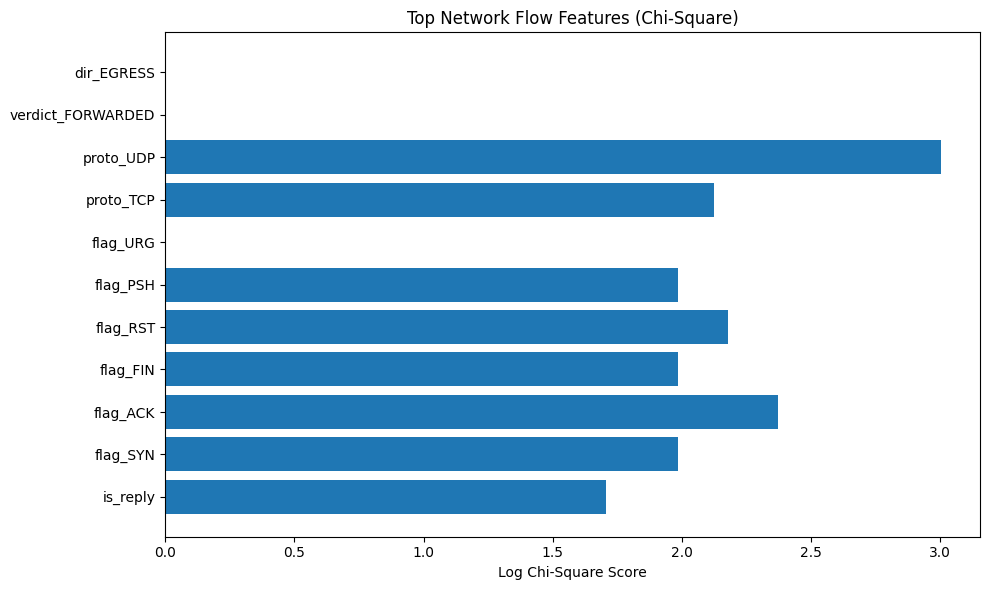

In [14]:
from sklearn.feature_selection import SelectKBest, chi2

X_flow = hubble_features.drop(columns=['label'])
y_flow = hubble_features['label']

X_flow = X_flow.abs()

k = min(20, X_flow.shape[1])  # Fallback kalau features < 20
selector = SelectKBest(chi2, k=k)
X_flow_selected = selector.fit_transform(X_flow, y_flow)

# Lihat top features
selected_mask = selector.get_support()
selected_features = X_flow.columns[selected_mask].tolist()

print(f'Selected top {k} features:')
for i, feat in enumerate(selected_features):
    print(f'  {i+1}. {feat}')

# Plot feature importance
scores = selector.scores_[selected_mask]
plt.figure(figsize=(10, 6))
plt.barh(selected_features, np.log1p(scores))
plt.xlabel('Log Chi-Square Score')
plt.title('Top Network Flow Features (Chi-Square)')
plt.tight_layout()
plt.savefig('output/feature_importance.png', dpi=150)
plt.show()

## Distribution

In [15]:
# --- Syscall Dataset ---
syscall_valid = syscall_ml_df[syscall_ml_df['label'] >= 0].copy()
X_syscall = syscall_valid[['n1', 'n2', 'n3', 'n4', 'n5']]
y_syscall = syscall_valid['label']

# Filter out classes with too few samples for stratification
min_samples = 2
label_counts = y_syscall.value_counts()
valid_labels = label_counts[label_counts >= min_samples].index
mask = y_syscall.isin(valid_labels)

X_syscall_filtered = X_syscall[mask]
y_syscall_filtered = y_syscall[mask]

# Syscall dataset summary
X_train_sys, X_test_sys, y_train_sys, y_test_sys = train_test_split(
    X_syscall_filtered, y_syscall_filtered,
    test_size=0.3,
    random_state=42,
    stratify=y_syscall_filtered
)

print('=== Syscall Dataset ===')
print(f'Train size: {len(X_train_sys)}')
print(f'Test size : {len(X_test_sys)}')
print('Train label distribution:')
print(y_train_sys.value_counts())

# Network flow Dataset
X_train_flow, X_test_flow, y_train_flow, y_test_flow = train_test_split(
    X_flow_selected, y_flow,
    test_size=0.3,
    random_state=42,
    stratify=y_flow
)

print('\n=== Network Flow Dataset ===')
print(f'Train size: {len(X_train_flow)}')
print(f'Test size : {len(X_test_flow)}')
print('Train label distribution:')
print(pd.Series(y_train_flow).value_counts())

=== Syscall Dataset ===
Train size: 3405
Test size : 1460
Train label distribution:
label
7    2957
1     448
Name: count, dtype: int64

=== Network Flow Dataset ===
Train size: 191
Test size : 83
Train label distribution:
label
1    138
7     53
Name: count, dtype: int64


## Imbalance

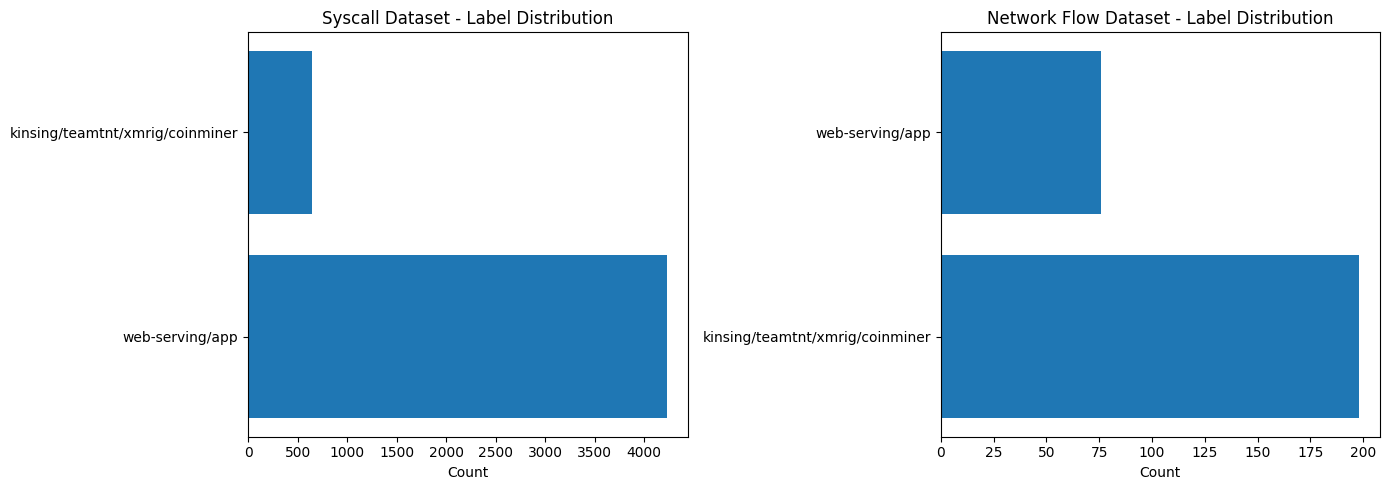

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Syscall
syscall_counts = y_syscall.map(LABEL_NAMES).value_counts()
axes[0].barh(syscall_counts.index, syscall_counts.values)
axes[0].set_title('Syscall Dataset - Label Distribution')
axes[0].set_xlabel('Count')

# Network flow
flow_counts = pd.Series(y_flow).map(LABEL_NAMES).value_counts()
axes[1].barh(flow_counts.index, flow_counts.values)
axes[1].set_title('Network Flow Dataset - Label Distribution')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('output/label_distribution.png', dpi=150)
plt.show()

## Save preprocesed dataset

In [17]:
# Save syscall dataset
syscall_valid.to_csv('dataset/syscall_dataset.csv', index=False)
print('Syscall dataset saved: syscall_dataset.csv')

# Save network flow dataset
flow_df_selected = pd.DataFrame(
    X_flow_selected, 
    columns=selected_features
)
flow_df_selected['label'] = y_flow.values
flow_df_selected.to_csv('dataset/network_flow_dataset.csv', index=False)
print('Network flow dataset saved: network_flow_dataset.csv')

# Save selector & scaler untuk IDS pipeline
joblib.dump(selector, 'dataset/feature_selector.pkl')
joblib.dump(selected_features, 'dataset/selected_features.pkl')

print(f'Syscall dataset    : {len(syscall_valid)} instances')
print(f'Network flow dataset: {len(flow_df_selected)} instances')
print(f'Selected features  : {selected_features}')

Syscall dataset saved: syscall_dataset.csv
Network flow dataset saved: network_flow_dataset.csv
Syscall dataset    : 4865 instances
Network flow dataset: 274 instances
Selected features  : ['is_reply', 'flag_SYN', 'flag_ACK', 'flag_FIN', 'flag_RST', 'flag_PSH', 'flag_URG', 'proto_TCP', 'proto_UDP', 'verdict_FORWARDED', 'dir_EGRESS', 'dir_INGRESS']
